# Wine Quality — Modelos de Regresión

Análisis exploratorio, preprocesamiento, entrenamiento y evaluación de:
- **Regresión Lineal Múltiple**
- **Regresión Polinomial** (grados 2 y 3)

**Variable objetivo:** `quality` (calidad del vino, puntuación 0-10).

## 1. Configuración del entorno

Se importan las librerías y los módulos del caso. Se agrega la raíz del proyecto al `sys.path` para poder importar `cases`.

In [1]:
import sys
from pathlib import Path

# Permite importar el paquete cases/ desde el notebook.
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from cases.wine_quality.config import (
    RESULTS_DIR, RANDOM_STATE, TEST_SIZE, TARGET, NUMERIC_FEATURES,
)
from cases.wine_quality.preprocessing import load_data, build_preprocessor
from cases.wine_quality.train import build_models
from cases.wine_quality.evaluate import metrics_table

print('Entorno listo. Python', sys.version.split()[0])

Entorno listo. Python 3.14.6


## 2. Carga del dataset real

Se carga `data/WineQT.csv`. La columna `Id` es un índice secuencial y no una propiedad del vino, por lo que se descarta al cargar.

In [2]:
df = load_data()
print('Dimensiones (filas, columnas):', df.shape)
print('Columnas:', list(df.columns))
df.head()

Dimensiones (filas, columnas): (1143, 12)
Columnas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3. Información general y tipos de datos

Todas las variables son numéricas (propiedades físico-químicas y la calidad). No hay variables categóricas.

In [3]:
df.info()
print()
print('Tipos de datos:')
print(df.dtypes.to_string())

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB

Tipos de datos:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          

## 4. Valores nulos

El dataset no presenta valores faltantes en ninguna columna.

In [4]:
nulos = df.isna().sum()
porcentaje = (df.isna().mean() * 100).round(3)
pd.DataFrame({'Nulos': nulos, 'Porcentaje %': porcentaje})

,Nulos,Porcentaje %
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


## 5. Duplicados

Se verifica la existencia de filas duplicadas.

In [5]:
print('Filas duplicadas:', df.duplicated().sum())

Filas duplicadas: 125


## 6. Estadísticas descriptivas

Resumen de las propiedades del vino. Las escalas son muy diferentes entre sí (por ejemplo, densidad ~0.997 frente a SO2 total de hasta 289), lo que justifica la estandarización.

In [6]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311,1.748,4.600,7.100,7.900,9.100,15.900
volatile acidity,1143.0,0.531,0.180,0.120,0.392,0.520,0.640,1.580
citric acid,1143.0,0.268,0.197,0.000,0.090,0.250,0.420,1.000
residual sugar,1143.0,2.532,1.356,0.900,1.900,2.200,2.600,15.500
chlorides,1143.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1143.0,15.615,10.250,1.000,7.000,13.000,21.000,68.000
total sulfur dioxide,1143.0,45.915,32.782,6.000,21.000,37.000,61.000,289.000
density,1143.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1143.0,3.311,0.157,2.740,3.205,3.310,3.400,4.010
sulphates,1143.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


## 7. Variable objetivo: quality

La calidad es **discreta**: toma valores enteros de 3 a 8 (6 niveles). Aunque es discreta, el ejercicio exige **regresión**, por lo que se trata como variable numérica continua.

Estadísticos de quality:
count    1143.000
mean        5.657
std         0.806
min         3.000
25%         5.000
50%         6.000
75%         6.000
max         8.000

Frecuencia de cada valor de calidad:
quality
3      6
4     33
5    483
6    462
7    143
8     16


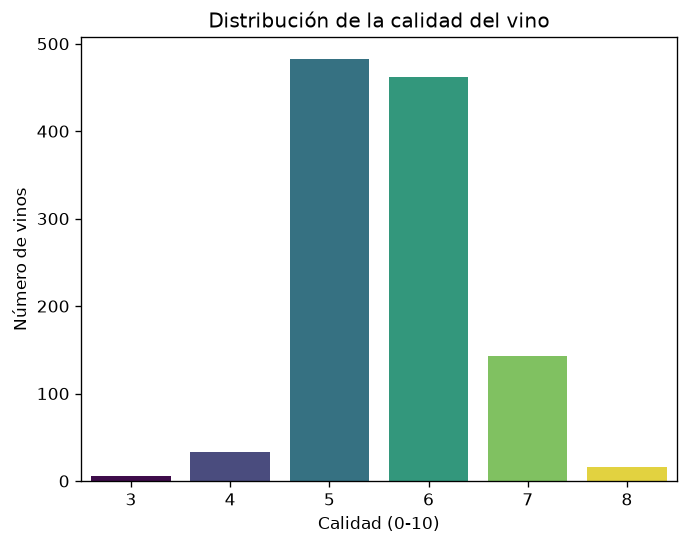

In [7]:
print('Estadísticos de quality:')
print(df['quality'].describe().round(3).to_string())
print()
print('Frecuencia de cada valor de calidad:')
print(df['quality'].value_counts().sort_index().to_string())

sns.countplot(x=df['quality'], hue=df['quality'], palette='viridis', legend=False)
plt.title('Distribución de la calidad del vino')
plt.xlabel('Calidad (0-10)')
plt.ylabel('Número de vinos')
plt.show()

## 8. Distribuciones de las propiedades

Histogramas de las variables físico-químicas. Varias son asimétricas a la derecha (residual sugar, chlorides, sulfur dioxide, sulphates).

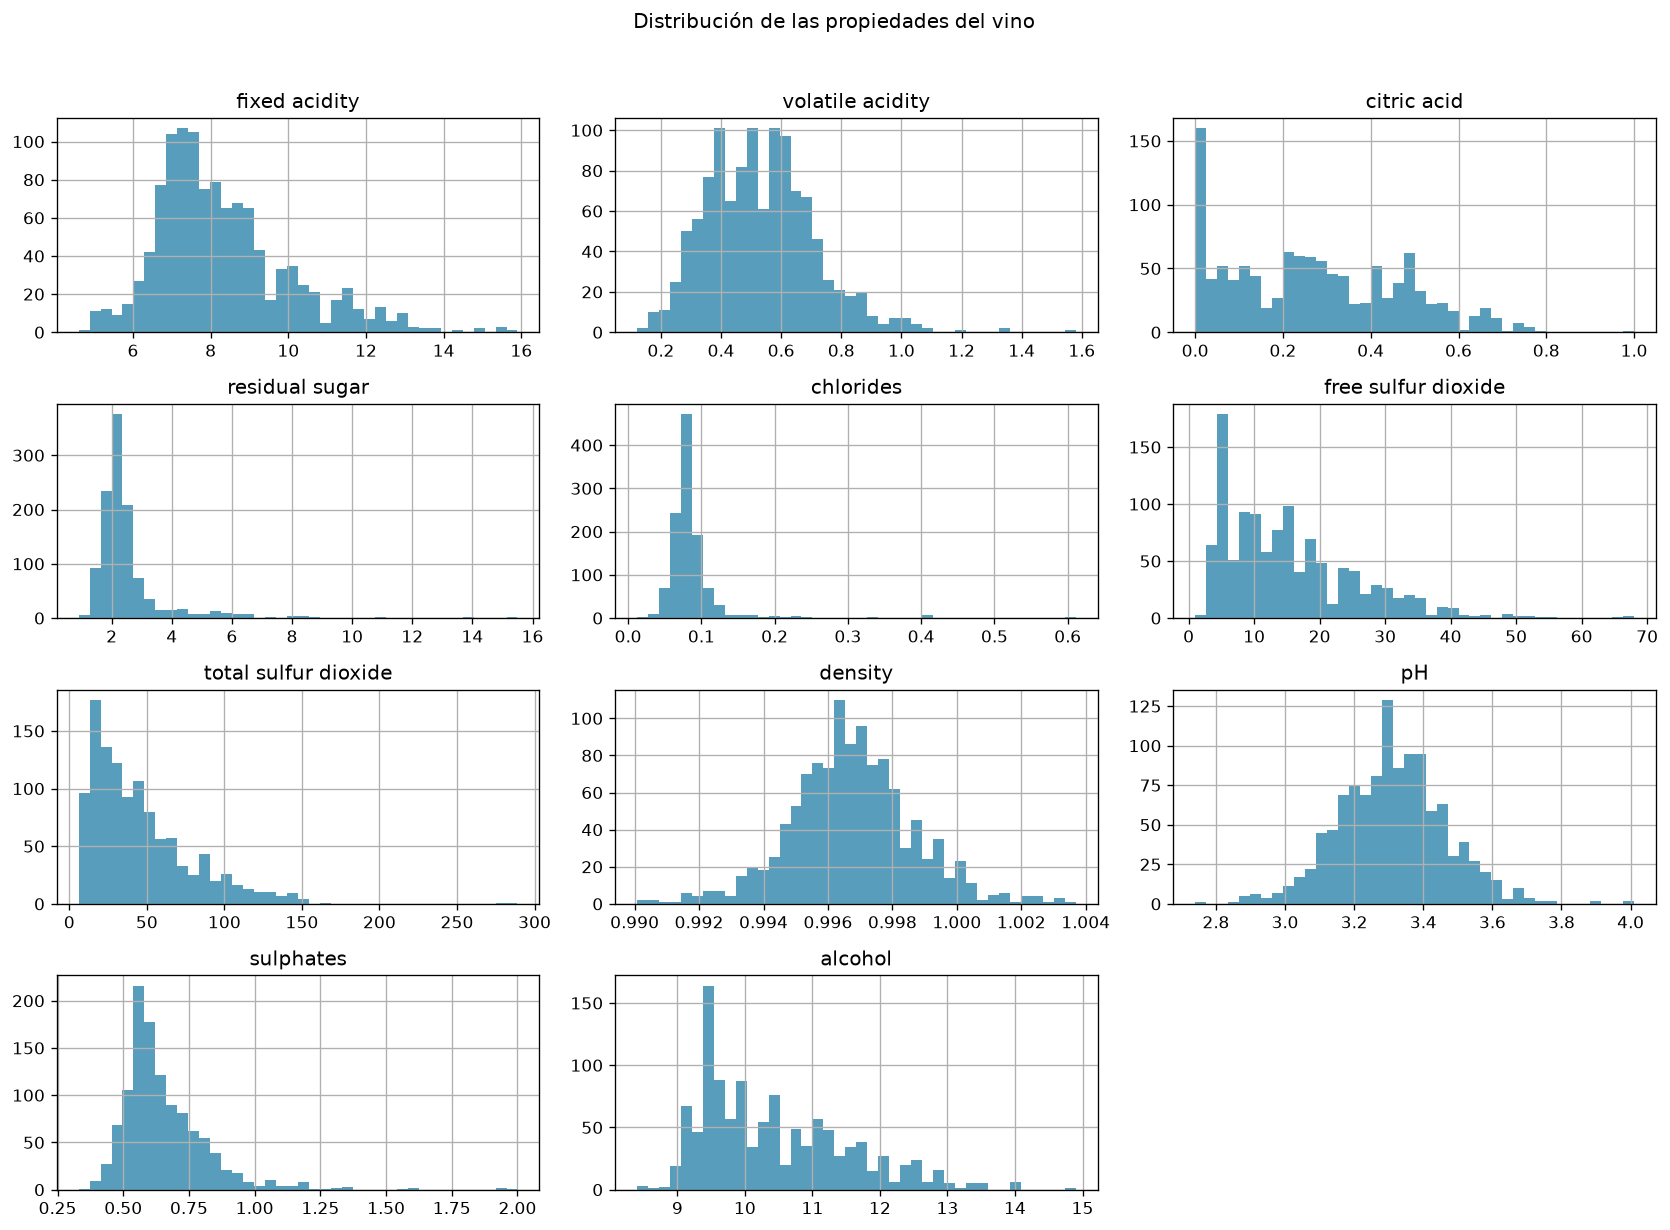

In [8]:
df[NUMERIC_FEATURES].hist(bins=40, figsize=(14, 10), color='#2E86AB', alpha=0.8)
plt.suptitle('Distribución de las propiedades del vino', y=1.02)
plt.tight_layout()
plt.show()

## 9. Análisis de outliers

Se usan boxplots y la regla del IQR. Variables como `residual sugar` (9.6%) y `chlorides` (6.7%) presentan valores extremos que corresponden a vinos reales con características atípicas (vinos dulces o muy salados); **se conservan** porque son observaciones válidas.

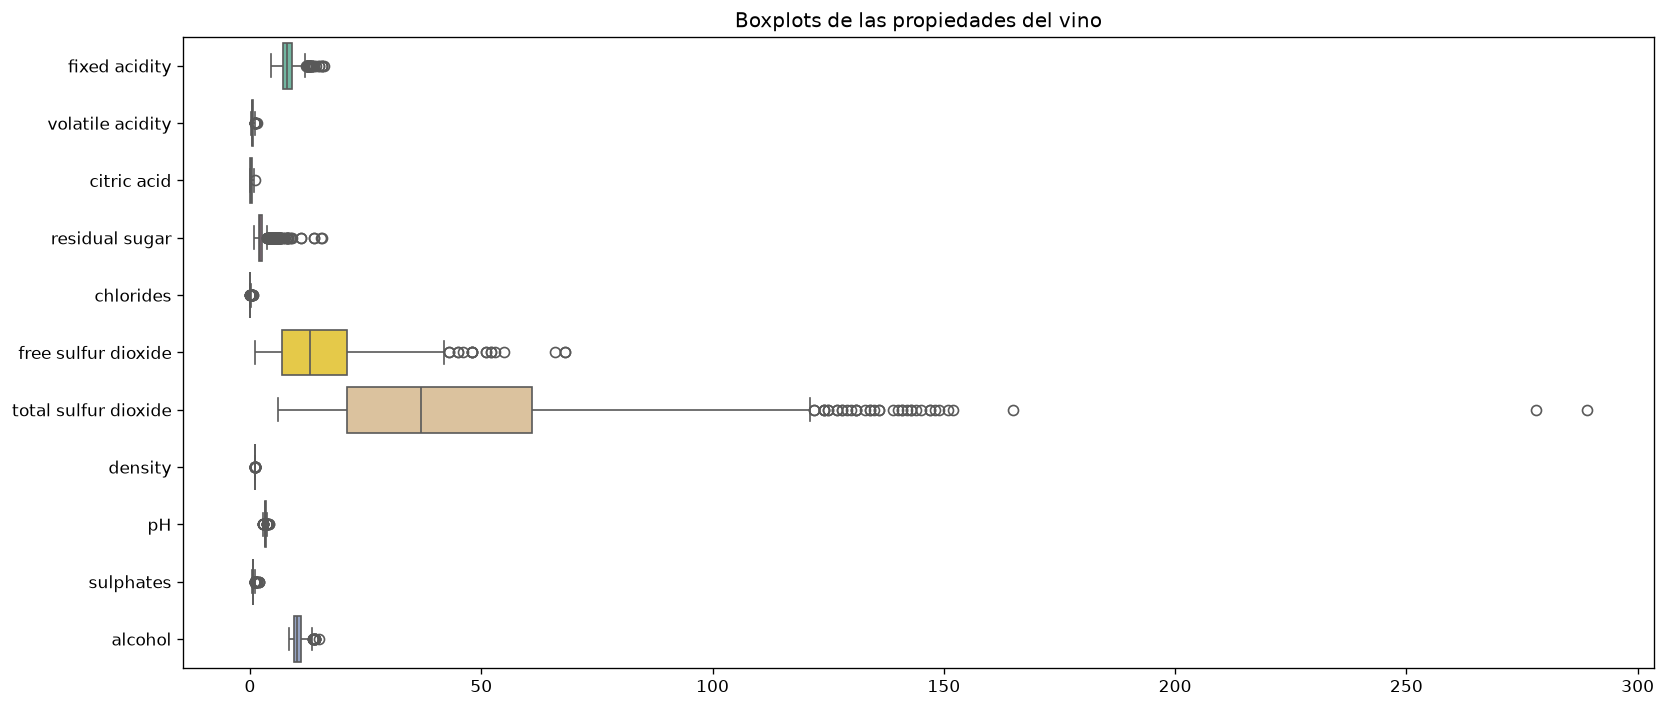

In [9]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[NUMERIC_FEATURES], orient='h', palette='Set2')
plt.title('Boxplots de las propiedades del vino')
plt.tight_layout()
plt.show()

In [10]:
print('Outliers por IQR:')
print(f"{'Variable':<24s} {'Outliers':>8s} {'%':>8s}")
for col in NUMERIC_FEATURES:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)
    print(f"{col:<24s} {int(mask.sum()):>8d} {100 * mask.mean():>7.2f}%")

Outliers por IQR:
Variable                 Outliers        %
fixed acidity                  44    3.85%
volatile acidity               14    1.22%
citric acid                     1    0.09%
residual sugar                110    9.62%
chlorides                      77    6.74%
free sulfur dioxide            18    1.57%
total sulfur dioxide           40    3.50%
density                        36    3.15%
pH                             20    1.75%
sulphates                      43    3.76%
alcohol                        12    1.05%


## 10. Matriz de correlación

Se muestra la correlación de Pearson. Los predictores más relacionados con la calidad son `alcohol` (+0.49) y `volatile acidity` (−0.41). Existen correlaciones altas entre predictores: `fixed acidity` con `citric acid` (0.67), `density` (0.68) y `pH` (−0.69); y `free SO2` con `total SO2` (0.66).

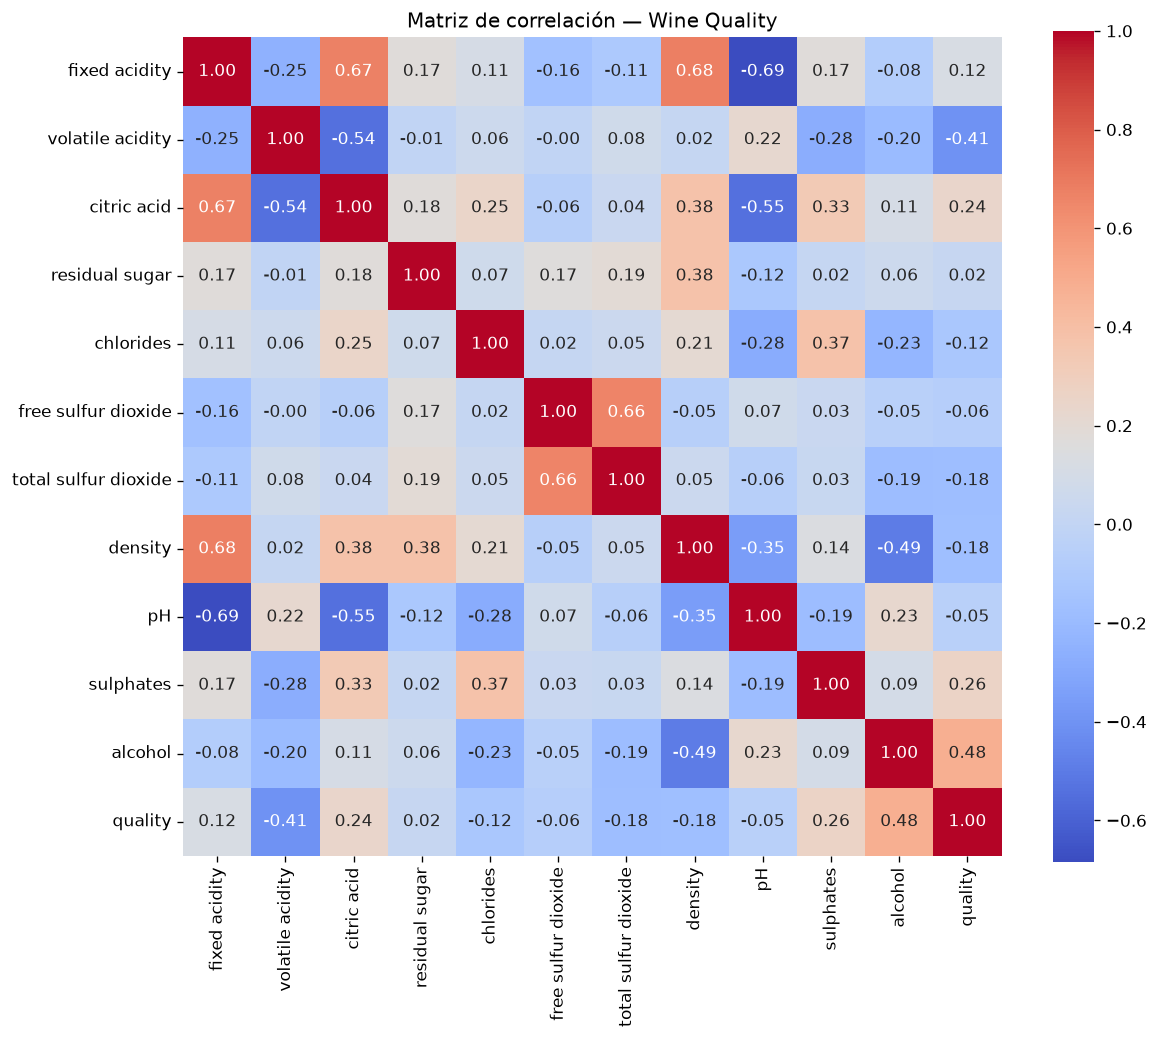

In [11]:
corr = df[NUMERIC_FEATURES + [TARGET]].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de correlación — Wine Quality')
plt.show()

In [12]:
print('Correlación con la calidad:')
print(corr[TARGET].sort_values(ascending=False).round(3).to_string())

Correlación con la calidad:
quality                 1.000
alcohol                 0.485
sulphates               0.258
citric acid             0.241
fixed acidity           0.122
residual sugar          0.022
pH                     -0.052
free sulfur dioxide    -0.063
chlorides              -0.124
density                -0.175
total sulfur dioxide   -0.183
volatile acidity       -0.407


## 11. Multicolinealidad (VIF)

El *Variance Inflation Factor* cuantifica la inflación de la varianza de cada coeficiente. Valores > 10 indican multicolinealidad severa. Aquí destacan `density` (1435), `pH` (1043) y `alcohol` (124), debido a las fuertes relaciones entre las propiedades del vino.

Consecuencia: los coeficientes individuales son poco estables. Sin embargo, la predicción global sigue siendo válida y **no se eliminan variables**, siguiendo el criterio del análisis.

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[NUMERIC_FEATURES].astype(float)
vif_table = []
for i in range(X_vif.shape[1]):
    vif = variance_inflation_factor(X_vif.to_numpy(), i)
    vif_table.append((X_vif.columns[i], round(vif, 2)))
pd.DataFrame(vif_table, columns=['Variable', 'VIF'])

,Variable,VIF
0,fixed acidity,74.55
1,volatile acidity,17.04
2,citric acid,9.22
3,residual sugar,5.01
4,chlorides,6.72
5,free sulfur dioxide,6.30
6,total sulfur dioxide,6.22
7,density,1435.10
8,pH,1043.34
9,sulphates,21.51


## 12. Preprocesamiento

Se construye un `ColumnTransformer` numérico: imputación con mediana (no hay nulos; se mantiene por robustez) + `StandardScaler`. Los transformadores se ajustan solo con el conjunto de entrenamiento para evitar data leakage.

In [14]:
preprocessor = build_preprocessor()
print('Preprocesador creado.')
preprocessor

Preprocesador creado.


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fe

## 13. División Train/Test

80% entrenamiento / 20% prueba con `random_state=42`.

In [15]:
X = df.drop(columns=[TARGET])
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')

Train: 914 filas | Test: 229 filas


## 14. Modelos y pipelines

Se entrenan los tres pipelines: Regresión Lineal Múltiple y Regresión Polinomial de grados 2 y 3 (78 y 364 características respectivamente).

In [16]:
models = build_models(preprocessor)
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    print(f'Entrenado: {name}')

Entrenado: linear_regression


Entrenado: polynomial_degree_2


Entrenado: polynomial_degree_3


## 15. Evaluación

Métricas en prueba: MAE, MSE, RMSE y R².

In [17]:
table = metrics_table(models, X_train, y_train, X_test, y_test)
table.round(3)

,Modelo,R2_train,RMSE_train,R2_test,RMSE_test,MAE_test,MSE_test
0,linear_regression,0.382,0.644,0.317,0.616,0.477,0.380
1,polynomial_degree_2,0.459,0.603,0.281,0.633,0.487,0.400
2,polynomial_degree_3,0.715,0.438,-6.469,2.039,0.866,4.156


## 16. Análisis de sobreajuste

Se comparan R² y RMSE de entrenamiento frente a prueba. Una gran brecha indica sobreajuste: el modelo memoriza el entrenamiento pero no generaliza.

In [18]:
over = table[['Modelo', 'R2_train', 'R2_test', 'RMSE_train', 'RMSE_test']]
over.round(3)

,Modelo,R2_train,R2_test,RMSE_train,RMSE_test
0,linear_regression,0.382,0.317,0.644,0.616
1,polynomial_degree_2,0.459,0.281,0.603,0.633
2,polynomial_degree_3,0.715,-6.469,0.438,2.039


## 17. Selección del mejor modelo

El **modelo lineal** obtiene el mejor R² en prueba (0.317). El grado 2 no mejora la predicción y el grado 3 **sobreajusta** severamente: su R² de entrenamiento (0.715) se desploma en prueba (−6.47).

In [19]:
best = table.loc[table['R2_test'].idxmax(), 'Modelo']
print('Mejor modelo (R² test):', best)
table.nlargest(1, 'R2_test').round(3)

Mejor modelo (R² test): linear_regression


,Modelo,R2_train,RMSE_train,R2_test,RMSE_test,MAE_test,MSE_test
0,linear_regression,0.382,0.644,0.317,0.616,0.477,0.38


## 18. Guardado de modelos

Los pipelines se guardan con `joblib` en `models/wine_quality/`; la aplicación Streamlit los carga sin reentrenarlos.

In [20]:
import joblib
from cases.wine_quality.config import MODELS_DIR

for name, pipeline in models.items():
    joblib.dump(pipeline, MODELS_DIR / f'{name}.pkl')
print('Modelos guardados en:', MODELS_DIR)

Modelos guardados en: C:\Users\alexl\OneDrive\Desktop\IA\Unidad1\Proyecto03\models\wine_quality


## 19. Predicción de ejemplo

Se predice la calidad de un vino tinto típico (medianas de cada propiedad).

In [21]:
from cases.wine_quality.predict import predict

sample = {
    'fixed acidity': 7.9, 'volatile acidity': 0.52, 'citric acid': 0.25,
    'residual sugar': 2.2, 'chlorides': 0.079, 'free sulfur dioxide': 13.0,
    'total sulfur dioxide': 37.0, 'density': 0.997, 'pH': 3.31,
    'sulphates': 0.62, 'alcohol': 10.2,
}

for key in models:
    print(f'{key:22s} -> {predict(key, sample):.3f} / 10')

linear_regression      -> 5.578 / 10
polynomial_degree_2    -> 5.629 / 10
polynomial_degree_3    -> 5.864 / 10


## 20. Conclusiones

- El dataset WineQT tiene 1,143 registros, sin nulos ni duplicados.
- `alcohol` y `volatile acidity` son los predictores más influyentes sobre la calidad.
- Existe multicolinealidad fuerte (VIF de density=1435, pH=1043); no se eliminaron variables y se interpretaron los coeficientes con cautela.
- El **modelo lineal** es el mejor (R² 0.317); la regresión polinomial de grado 2 no aporta y el grado 3 **sobreajusta** (R² test −6.47).
- La calidad es discreta (3-8) pero se modela como variable continua por el planteamiento de regresión del ejercicio.